# Bloc 1 — « Evidence » : EDA de la détection de fraude à l'assurance auto

**Projet Applied ML — Albert School × Mines Paris-PSL.**
Détection de fraude sur sinistres auto (`carclaims`, 15 420 sinistres, 1994-1996).

Le modèle est un **outil de triage** : il signale des sinistres à envoyer en
investigation humaine, il ne refuse aucun paiement.
- **Faux positif** = coût d'enquête + friction client.
- **Faux négatif** = fraude payée.

Ce notebook **décrit et décide** uniquement : aucun modèle, aucun split, aucun
encodage de modélisation. Toute la logique vit dans [`src/eda.py`](../src/eda.py) ;
ici on ne fait qu'appeler et commenter.

**Règles suivies :** taille d'effet (V de Cramér, différence de taux) rapportée à
côté de chaque p-value ; correction de Benjamini-Hochberg pour les tests
multiples ; pas d'interprétation ponctuelle sous n < 30 (on montre l'IC) ;
association ≠ causalité ; seed fixée ; tout chiffre du texte provient d'une
variable calculée.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))
import eda

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
np.random.seed(eda.RANDOM_STATE)

FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = eda.load_data()
N = len(df)
print(f"{N:,} sinistres × {df.shape[1]} colonnes (dont y et FraudFound)")
print(f"Colonnes catégorielles analysées : {len(eda.feature_columns(df))}")

15,420 sinistres × 34 colonnes (dont y et FraudFound)
Colonnes catégorielles analysées : 30


## 1. Audit qualité des données

Avant toute statistique : que contient chaque colonne, qu'est-ce qui est
identifiant, qu'est-ce qui est incohérent ?

In [2]:
# 1.1 — Modalités uniques et manquants par colonne
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    "n_missing": df.isna().sum(),
    "exemple": [", ".join(map(str, pd.Series(df[c].dropna().unique())[:3])) for c in df.columns],
})
audit

,dtype,n_unique,n_missing,exemple
Month,category,12,0,"Dec, Jan, Oct"
WeekOfMonth,category,5,0,"5, 3, 2"
DayOfWeek,category,7,0,"Wednesday, Friday, Saturday"
Make,category,19,0,"Honda, Toyota, Ford"
AccidentArea,category,2,0,"Urban, Rural"
DayOfWeekClaimed,category,7,1,"Tuesday, Monday, Thursday"
MonthClaimed,category,12,1,"Jan, Nov, Jul"
WeekOfMonthClaimed,category,5,0,"1, 4, 2"
Sex,category,2,0,"Female, Male"
MaritalStatus,category,4,0,"Single, Married, Widow"


In [3]:
# 1.2 — PolicyNumber : identifiant unique, strictement croissant, aligné années
pn = df["PolicyNumber"]
print("unique :", pn.is_unique, "| strictement croissant :", pn.is_monotonic_increasing)
print("plage  :", pn.min(), "->", pn.max())
rng = (df.groupby("Year")["PolicyNumber"].agg(["min", "max", "size"]))
print("\nPlage de PolicyNumber par année (proxy temporel) :")
print(rng)
# -> PolicyNumber n'est pas une feature : c'est un ID ET l'axe du temps.

unique : True | strictement croissant : True
plage  : 1 -> 15420

Plage de PolicyNumber par année (proxy temporel) :
        min    max  size
Year                    
1994      1   6142  6142
1995   6143  11337  5195
1996  11338  15420  4083


In [4]:
# 1.3 — Age == 0 : codage, pas un âge réel
mask_age0 = df["Age"] == 0
age0 = df[mask_age0]
n_age0 = int(mask_age0.sum())
rate_age0 = float(age0["y"].mean())
print(f"Age == 0 : {n_age0} lignes | AgeOfPolicyHolder =",
      dict(age0["AgeOfPolicyHolder"].value_counts()))
print(f"Taux de fraude sur Age==0 : {rate_age0:.4%} (vs global {df['y'].mean():.4%})")
# Age==0 coexiste toujours avec 'AgeOfPolicyHolder = 16 to 17' -> sentinelle de saisie.

Age == 0 : 320 lignes | AgeOfPolicyHolder = {'16 to 17': np.int64(320), '18 to 20': np.int64(0), '21 to 25': np.int64(0), '26 to 30': np.int64(0), '31 to 35': np.int64(0), '36 to 40': np.int64(0), '41 to 50': np.int64(0), '51 to 65': np.int64(0), 'over 65': np.int64(0)}
Taux de fraude sur Age==0 : 9.6875% (vs global 5.9857%)


In [5]:
# 1.4 — La ligne '0' de date de déclaration (passée en NaN au chargement)
bad = df[df["MonthClaimed"].isna() | df["DayOfWeekClaimed"].isna()]
print(f"Lignes avec date de déclaration invalide : {len(bad)}")
bad[["PolicyNumber", "Month", "MonthClaimed", "DayOfWeek", "DayOfWeekClaimed", "y"]]

Lignes avec date de déclaration invalide : 1


,PolicyNumber,Month,MonthClaimed,DayOfWeek,DayOfWeekClaimed,y
1516,1517,Jul,NaN,Monday,NaN,0


In [6]:
# 1.5 — Doublons hors PolicyNumber
dup_excl_id = int(df.drop(columns=["PolicyNumber"]).duplicated().sum())
print(f"Lignes identiques une fois PolicyNumber retiré : {dup_excl_id}")
# 0 -> pas de doublon caché ; chaque ligne est un sinistre distinct.

Lignes identiques une fois PolicyNumber retiré : 0


In [7]:
# 1.6 — Redondances PolicyType / BasePolicy / VehicleCategory
print("PolicyType × BasePolicy (chaque PolicyType -> une seule BasePolicy) :")
ct_pb = pd.crosstab(df["PolicyType"], df["BasePolicy"])
print(ct_pb)
det = (ct_pb > 0).sum(axis=1)
print("\nNb de BasePolicy distinctes par PolicyType :", dict(det))
print("=> BasePolicy est entièrement déterminée par PolicyType.\n")

print("PolicyType × VehicleCategory :")
ct_pv = pd.crosstab(df["PolicyType"], df["VehicleCategory"])
print(ct_pv)
sl = df[df["PolicyType"] == "Sedan - Liability"]
print(f"\n'Sedan - Liability' : {len(sl)} lignes, VehicleCategory =",
      dict(sl["VehicleCategory"].value_counts()))
print("=> incohérence : toutes ces 'Sedan' sont étiquetées 'Sport'.")

PolicyType × BasePolicy (chaque PolicyType -> une seule BasePolicy) :
BasePolicy            All Perils  Collision  Liability
PolicyType                                            
Sedan - All Perils          4087          0          0
Sedan - Collision              0       5584          0
Sedan - Liability              0          0       4987
Sport - All Perils            22          0          0
Sport - Collision              0        348          0
Sport - Liability              0          0          1
Utility - All Perils         340          0          0
Utility - Collision            0         30          0
Utility - Liability            0          0         21

Nb de BasePolicy distinctes par PolicyType : {'Sedan - All Perils': np.int64(1), 'Sedan - Collision': np.int64(1), 'Sedan - Liability': np.int64(1), 'Sport - All Perils': np.int64(1), 'Sport - Collision': np.int64(1), 'Sport - Liability': np.int64(1), 'Utility - All Perils': np.int64(1), 'Utility - Collision': np.int64(1),

## 2. Déséquilibre de classe et baselines

La fraude est rare. Toute métrique et toute baseline doivent en tenir compte :
un modèle qui prédit toujours « No » a une accuracy trompeusement élevée.

In [8]:
n_fraud = int(df["y"].sum())
prevalence = n_fraud / N
ci_lo, ci_hi = eda.wilson_ci(n_fraud, N)
baseline_acc = 1 - prevalence          # accuracy du modèle "toujours No"
pr_auc_random = prevalence             # PR-AUC d'un classifieur aléatoire = prévalence

print(f"Fraudes            : {n_fraud:,} / {N:,}")
print(f"Prévalence (taux)  : {prevalence:.4%}  IC Wilson 95% [{ci_lo:.4%}, {ci_hi:.4%}]")
print(f"Baseline accuracy 'toujours No' : {baseline_acc:.4%}")
print(f"PR-AUC aléatoire (= prévalence) : {pr_auc_random:.4f}")
print("\n=> L'accuracy est inutile : 94% se bat sans rien prédire.")
print("=> La métrique doit vivre sur l'axe précision/rappel (PR-AUC, recall@budget).")

Fraudes            : 923 / 15,420
Prévalence (taux)  : 5.9857%  IC Wilson 95% [5.6222%, 6.3712%]
Baseline accuracy 'toujours No' : 94.0143%
PR-AUC aléatoire (= prévalence) : 0.0599

=> L'accuracy est inutile : 94% se bat sans rien prédire.
=> La métrique doit vivre sur l'axe précision/rappel (PR-AUC, recall@budget).


## 3. Association univariée avec la cible

Un chi² d'indépendance par variable catégorielle vs la cible, **taille d'effet**
(V de Cramér corrigé du biais de Bergsma) rapportée à côté de la p-value, et
p ajustée par Benjamini-Hochberg. Tri par **taille d'effet**, pas par p-value :
à n = 15 420 presque tout est « significatif », seul l'effet discrimine.

In [9]:
report = eda.assoc_report(df)
n_tests = report.attrs["n_tests"]
n_sig = int(report["significant_bh"].sum())
print(f"{n_tests} tests du chi² réalisés (une variable catégorielle chacun).")
print(f"{n_sig}/{n_tests} restent significatifs après Benjamini-Hochberg (FDR 5%).")
report

30 tests du chi² réalisés (une variable catégorielle chacun).
19/30 restent significatifs après Benjamini-Hochberg (FDR 5%).


,variable,n,k_levels,dof,chi2,p_value,cramers_v,p_value_bh,significant_bh
0,PolicyType,15420,9,8,437.4019,0.0000,0.1669,0.0000,True
1,BasePolicy,15420,3,2,402.8519,0.0000,0.1612,0.0000,True
2,VehicleCategory,15420,3,2,290.9421,0.0000,0.1369,0.0000,True
3,Fault,15420,2,1,266.1974,0.0000,0.1311,0.0000,True
4,AddressChange-Claim,15420,5,4,104.7338,0.0000,0.0808,0.0000,True
5,Deductible,15420,4,3,72.4152,0.0000,0.0671,0.0000,True
6,VehiclePrice,15420,6,5,67.7683,0.0000,0.0638,0.0000,True
7,PastNumberOfClaims,15420,4,3,53.5008,0.0000,0.0572,0.0000,True
8,Make,15420,19,18,59.8100,0.0000,0.0521,0.0000,True
9,MonthClaimed,15419,12,11,42.2005,0.0000,0.0450,0.0000,True


Top 6 par V de Cramér : ['PolicyType', 'BasePolicy', 'VehicleCategory', 'Fault', 'AddressChange-Claim', 'Deductible']


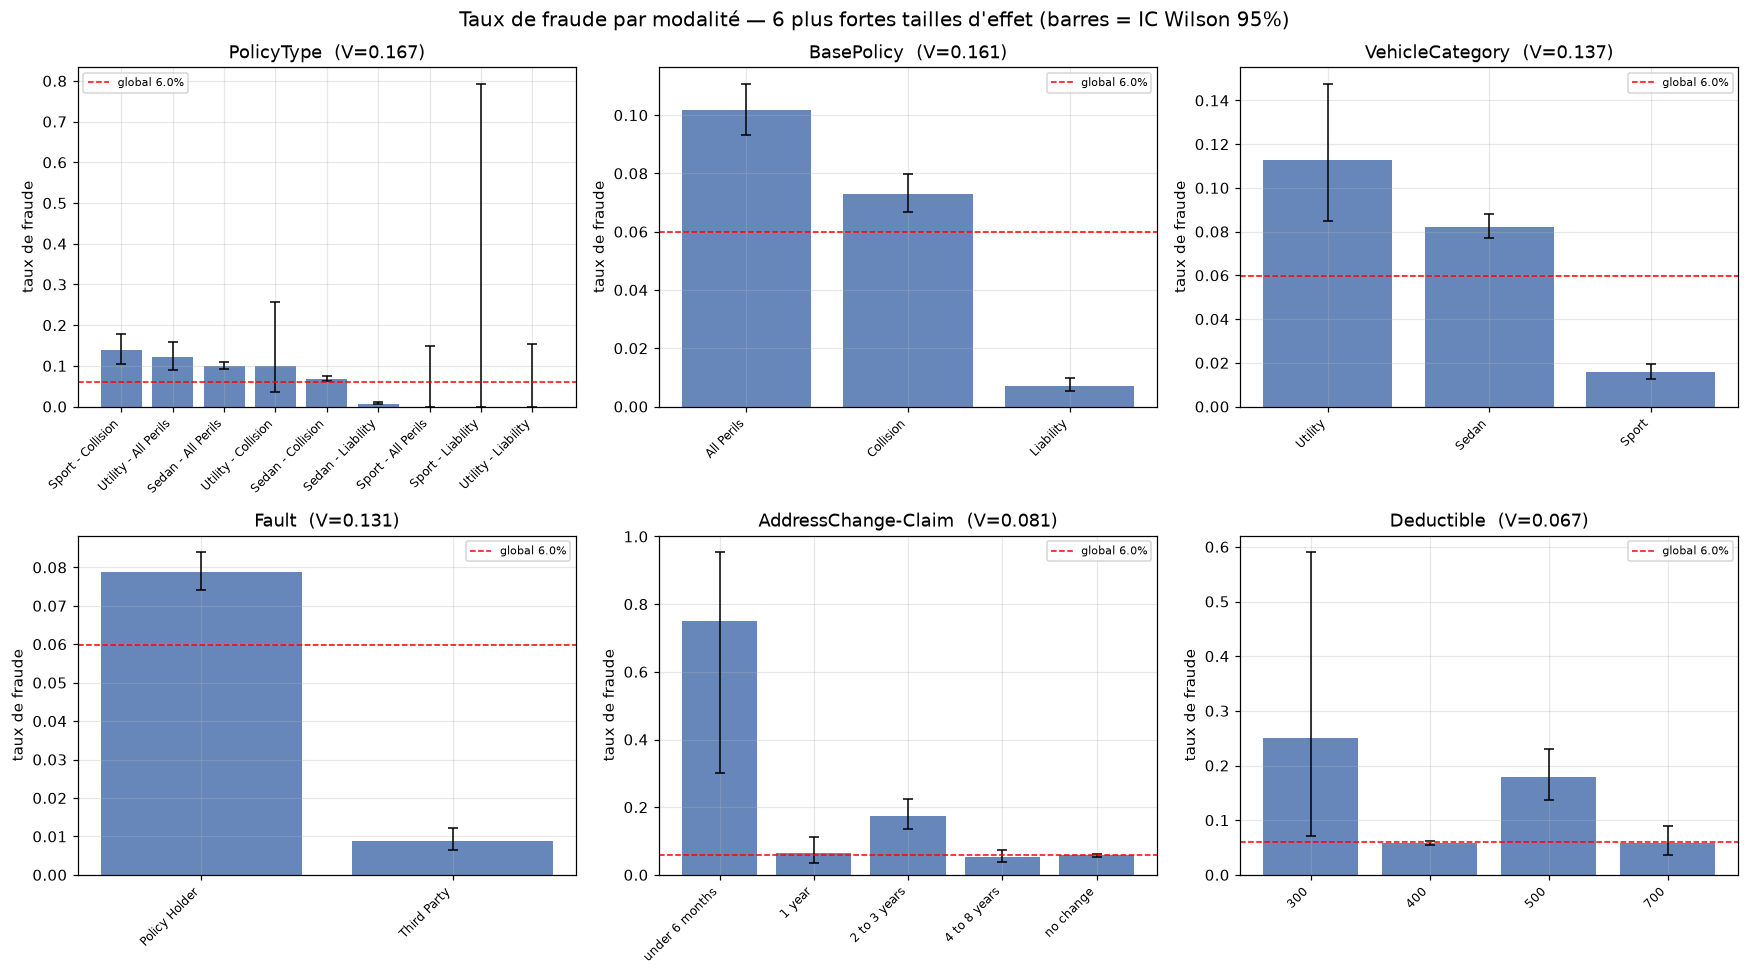

In [10]:
# Les 6 plus fortes tailles d'effet : taux de fraude par modalité + IC de Wilson.
top6 = report["variable"].head(6).tolist()
print("Top 6 par V de Cramér :", top6)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), top6):
    rt = eda.rate_table(df, col)
    x = np.arange(len(rt))
    yerr = np.clip(np.vstack([rt["rate"] - rt["ci_low"], rt["ci_high"] - rt["rate"]]), 0, None)
    ax.bar(x, rt["rate"], color="#4C72B0", alpha=0.85)
    ax.errorbar(x, rt["rate"], yerr=yerr, fmt="none", ecolor="black", capsize=3, lw=1)
    ax.axhline(prevalence, color="red", ls="--", lw=1, label=f"global {prevalence:.1%}")
    ax.set_title(f"{col}  (V={report.loc[report.variable==col,'cramers_v'].iat[0]:.3f})")
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in rt[col]], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("taux de fraude")
    ax.legend(fontsize=7)
fig.suptitle("Taux de fraude par modalité — 6 plus fortes tailles d'effet (barres = IC Wilson 95%)",
             fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "top6_fraud_rate_by_modality.png", bbox_inches="tight")
plt.show()

In [11]:
# Lecture métier des deux plus forts effets (association, pas causalité).
print("Fault :")
print(eda.rate_table(df, "Fault").to_string(index=False))
print("\nBasePolicy :")
print(eda.rate_table(df, "BasePolicy").to_string(index=False))
print("\nAttention redondance : PolicyType, BasePolicy et VehicleCategory")
print("mesurent la même chose (cf. §1.6) -> ne pas les cumuler comme 3 features.")

Fault :
        Fault     n  n_fraud   rate  ci_low  ci_high  ci_width
Policy Holder 11230      886 0.0789  0.0741   0.0840    0.0100
  Third Party  4190       37 0.0088  0.0064   0.0121    0.0057

BasePolicy :
BasePolicy    n  n_fraud   rate  ci_low  ci_high  ci_width
All Perils 4449      452 0.1016  0.0931   0.1108    0.0178
 Collision 5962      435 0.0730  0.0666   0.0798    0.0132
 Liability 5009       36 0.0072  0.0052   0.0099    0.0047

Attention redondance : PolicyType, BasePolicy et VehicleCategory
mesurent la même chose (cf. §1.6) -> ne pas les cumuler comme 3 features.


## 4. Dérive temporelle

`PolicyNumber` et `Year` ordonnent le temps (§1.2). Le taux de fraude baisse-t-il
sur 1994→1996 ? Si oui, un split aléatoire fuite le futur dans le passé.

In [12]:
# 4.1 — Taux par année avec IC de Wilson
year_tab = eda.rate_table(df, "Year")
print(year_tab.to_string(index=False))

# 4.2 — Test de tendance de Cochran-Armitage (tient compte de l'ordre des années)
ca = eda.cochran_armitage_trend(df, "Year")
print(f"\nCochran-Armitage : z = {ca['z']:.3f}, p = {ca['p_value']:.4g}"
      f" -> tendance {ca['slope_sign']}")

# 4.3 — chi² sur la table 3×2 (sans hypothèse d'ordre), pour comparaison
from scipy.stats import chi2_contingency
chi2_y, p_y, dof_y, _ = chi2_contingency(pd.crosstab(df["Year"], df["y"]), correction=False)
print(f"chi² table 3×2   : chi² = {chi2_y:.3f}, ddl = {dof_y}, p = {p_y:.4g}")
drop_pts = (year_tab['rate'].iloc[0] - year_tab['rate'].iloc[-1]) * 100
print(f"\nBaisse absolue 1994->1996 : {drop_pts:.2f} points de %.")
print("=> Dérive réelle et significative : le split DOIT être temporel.")

 Year    n  n_fraud   rate  ci_low  ci_high  ci_width
 1994 6142      409 0.0666  0.0606   0.0731    0.0125
 1995 5195      301 0.0579  0.0519   0.0646    0.0127
 1996 4083      213 0.0522  0.0458   0.0594    0.0137

Cochran-Armitage : z = -3.075, p = 0.002108 -> tendance décroissant
chi² table 3×2   : chi² = 9.578, ddl = 2, p = 0.008321

Baisse absolue 1994->1996 : 1.44 points de %.
=> Dérive réelle et significative : le split DOIT être temporel.


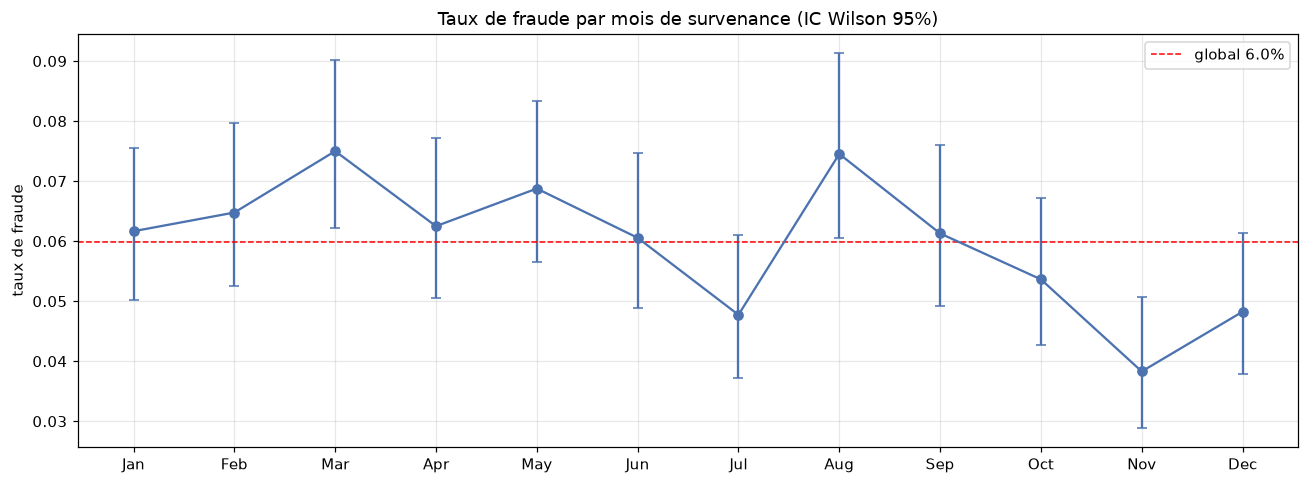

Month : V de Cramér = 0.035, p_BH = 0.003411
=> Effet saisonnier faible ; les IC se chevauchent largement.


In [13]:
# 4.4 — Saisonnalité : taux par mois de survenance (avec IC)
month_tab = eda.rate_table(df, "Month")
fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(len(month_tab))
yerr = np.clip(np.vstack([month_tab["rate"] - month_tab["ci_low"],
                  month_tab["ci_high"] - month_tab["rate"]]), 0, None)
ax.errorbar(x, month_tab["rate"], yerr=yerr, fmt="o-", capsize=3, color="#4C72B0")
ax.axhline(prevalence, color="red", ls="--", lw=1, label=f"global {prevalence:.1%}")
ax.set_xticks(x); ax.set_xticklabels(month_tab["Month"])
ax.set_ylabel("taux de fraude"); ax.set_title("Taux de fraude par mois de survenance (IC Wilson 95%)")
ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "fraud_rate_by_month.png", bbox_inches="tight")
plt.show()

v_month = report.loc[report.variable == "Month", "cramers_v"].iat[0]
p_month = report.loc[report.variable == "Month", "p_value_bh"].iat[0]
print(f"Month : V de Cramér = {v_month:.3f}, p_BH = {p_month:.4g}")
print("=> Effet saisonnier faible ; les IC se chevauchent largement.")

## 5. Slices à risque (à auditer par le bloc 4 — équité / robustesse)

Taux de fraude par segment sensible ou opérationnel, avec IC. Ce sont les
tranches sur lesquelles le modèle devra être audité (biais, sous-performance).

In [14]:
slice_cols = ["Sex", "AgentType", "AccidentArea"]
for col in slice_cols:
    print(f"--- {col} ---")
    print(eda.rate_table(df, col).to_string(index=False))
    print()

# Groupe Age==0 (sentinelle mineurs '16 to 17') vs le reste
grp = np.where(mask_age0, "Age==0 (sentinelle)", "Age>0")
tmp = df.assign(_grp=grp)
rt_age = tmp.groupby("_grp")["y"].agg(n="size", n_fraud="sum")
rt_age["rate"] = rt_age["n_fraud"] / rt_age["n"]
rt_age[["ci_low", "ci_high"]] = [eda.wilson_ci(int(f), int(n))
                                 for f, n in zip(rt_age["n_fraud"], rt_age["n"])]
print("--- Groupe Age==0 ---")
print(rt_age)

--- Sex ---
   Sex     n  n_fraud   rate  ci_low  ci_high  ci_width
  Male 13000      818 0.0629  0.0589   0.0672    0.0084
Female  2420      105 0.0434  0.0360   0.0523    0.0163

--- AgentType ---
AgentType     n  n_fraud   rate  ci_low  ci_high  ci_width
 External 15179      919 0.0605  0.0569   0.0645    0.0076
 Internal   241        4 0.0166  0.0065   0.0419    0.0354

--- AccidentArea ---
AccidentArea     n  n_fraud   rate  ci_low  ci_high  ci_width
       Rural  1598      133 0.0832  0.0707   0.0978    0.0271
       Urban 13822      790 0.0572  0.0534   0.0611    0.0077

--- Groupe Age==0 ---
                         n  n_fraud   rate  ci_low  ci_high
_grp                                                       
Age==0 (sentinelle)    320       31 0.0969  0.0691   0.1342
Age>0                15100      892 0.0591  0.0554   0.0629


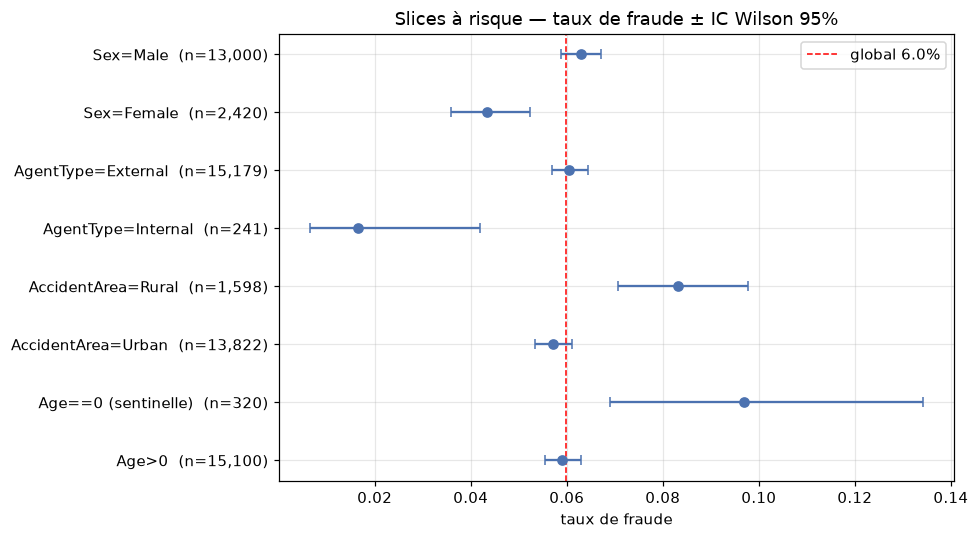

In [15]:
# Visualisation compacte des slices (taux ± IC Wilson)
seg_rows = []
for col in slice_cols:
    rt = eda.rate_table(df, col)
    for _, r in rt.iterrows():
        seg_rows.append((f"{col}={r[col]}", r["rate"], r["ci_low"], r["ci_high"], r["n"]))
for idx, r in rt_age.reset_index().iterrows():
    seg_rows.append((r["_grp"], r["rate"], r["ci_low"], r["ci_high"], r["n"]))
seg = pd.DataFrame(seg_rows, columns=["segment", "rate", "lo", "hi", "n"])

fig, ax = plt.subplots(figsize=(9, 0.5 * len(seg) + 1))
y = np.arange(len(seg))
xerr = np.clip(np.vstack([seg["rate"] - seg["lo"], seg["hi"] - seg["rate"]]), 0, None)
ax.errorbar(seg["rate"], y, xerr=xerr, fmt="o", capsize=3, color="#4C72B0")
ax.axvline(prevalence, color="red", ls="--", lw=1, label=f"global {prevalence:.1%}")
ax.set_yticks(y); ax.set_yticklabels([f"{s}  (n={n:,})" for s, n in zip(seg['segment'], seg['n'])])
ax.invert_yaxis(); ax.set_xlabel("taux de fraude"); ax.legend()
ax.set_title("Slices à risque — taux de fraude ± IC Wilson 95%")
fig.tight_layout(); fig.savefig(FIG_DIR / "risk_slices.png", bbox_inches="tight")
plt.show()

## 6. Implications pour le protocole d'évaluation

Section décisionnelle. Chaque décision renvoie à un chiffre produit plus haut ;
le texte ci-dessous est **généré à partir des variables calculées** (aucun chiffre
codé en dur).

In [16]:
from IPython.display import Markdown, display

# Chiffres réutilisés
v_ptype = report.loc[report.variable == "PolicyType", "cramers_v"].iat[0]
v_base = report.loc[report.variable == "BasePolicy", "cramers_v"].iat[0]
v_vcat = report.loc[report.variable == "VehicleCategory", "cramers_v"].iat[0]
v_fault = report.loc[report.variable == "Fault", "cramers_v"].iat[0]
ordinals = ", ".join(sorted(eda.ORDINAL_ORDERS))

txt = f'''
### Décisions

**1. Métrique principale : PR-AUC (aire précision-rappel), + rappel @ budget d'enquêtes.**
La prévalence est de **{prevalence:.2%}** (IC Wilson [{ci_lo:.2%}, {ci_hi:.2%}], §2).
L'accuracy est disqualifiée : un modèle « toujours No » atteint **{baseline_acc:.2%}**.
Baseline honnête = PR-AUC aléatoire = **{pr_auc_random:.3f}**. Comme l'outil est un
triage à capacité d'enquête finie, on suit aussi le **rappel au seuil de budget**
(part de fraudes captées dans les k% de sinistres les mieux notés).

**2. Split : TEMPOREL, par `PolicyNumber`/`Year`, jamais aléatoire.**
Le taux baisse de **{drop_pts:.2f} points** de 1994 à 1996 (Cochran-Armitage
z = {ca['z']:.2f}, p = {ca['p_value']:.4f}, §4). Entraîner sur 1994-1995, tester sur
1996 reproduit le déploiement réel et évite la fuite du futur. `PolicyNumber` étant
croissant dans le temps (§1.2), il définit l'ordre du split — et n'est **jamais** une feature.

**3. Catégories rares (n < 30) : regrouper, ne pas se fier au taux ponctuel.**
`AddressChange-Claim = "under 6 months"` : {int((df['AddressChange-Claim']=='under 6 months').sum())}
sinistres seulement, IC de Wilson très large (§3) -> non concluant isolément.
`Deductible = 300` : {int((df['Deductible']==300).sum())} lignes. Décision : fusionner ces
modalités rares (ou lissage bayésien du taux) **en apprenant le regroupement sur le
train seul**, pour ne pas fuiter.

**4. Variables à retirer :**
- `PolicyNumber` : identifiant + proxy temporel (§1.2) -> fuite garantie comme feature.
- `FraudFound` : source de la cible.
- **Une** des deux parmi `PolicyType` / `BasePolicy` : redondantes (BasePolicy
  entièrement déterminée par PolicyType, §1.6 ; V = {v_ptype:.3f} vs {v_base:.3f}).
  Garder `PolicyType` (plus fin) OU `BasePolicy` (plus stable), pas les deux.
- `VehicleCategory` (V = {v_vcat:.3f}) : suspecte — les 4 987 « Sedan - Liability »
  sont toutes étiquetées « Sport » (§1.6). À écarter ou reconstruire avant usage.

**5. Variables ordinales à encoder en ordinal (ordre métier, cf. `ORDINAL_ORDERS`) :**
{ordinals}.
Elles sont stockées en texte de plage ; l'ordre alphabétique est faux. Encodage
ordinal (et non one-hot) pour préserver la monotonie. `Age==0` est une sentinelle
« 16-17 ans » ({n_age0} lignes, §1.3) : à traiter comme catégorie/`NaN`, pas comme âge 0.

**6. Garde-fous statistiques.** {n_tests} tests menés, {n_sig} significatifs après
Benjamini-Hochberg. À n = {N:,} la significativité seule ne prouve rien : seules les
tailles d'effet comptent (max V de Cramér = {v_ptype:.3f}, effet modéré). `Fault`
(V = {v_fault:.3f}) est un signal fort et légitime. **Association ≠ causalité.**
'''
display(Markdown(txt))


### Décisions

**1. Métrique principale : PR-AUC (aire précision-rappel), + rappel @ budget d'enquêtes.**
La prévalence est de **5.99%** (IC Wilson [5.62%, 6.37%], §2).
L'accuracy est disqualifiée : un modèle « toujours No » atteint **94.01%**.
Baseline honnête = PR-AUC aléatoire = **0.060**. Comme l'outil est un
triage à capacité d'enquête finie, on suit aussi le **rappel au seuil de budget**
(part de fraudes captées dans les k% de sinistres les mieux notés).

**2. Split : TEMPOREL, par `PolicyNumber`/`Year`, jamais aléatoire.**
Le taux baisse de **1.44 points** de 1994 à 1996 (Cochran-Armitage
z = -3.07, p = 0.0021, §4). Entraîner sur 1994-1995, tester sur
1996 reproduit le déploiement réel et évite la fuite du futur. `PolicyNumber` étant
croissant dans le temps (§1.2), il définit l'ordre du split — et n'est **jamais** une feature.

**3. Catégories rares (n < 30) : regrouper, ne pas se fier au taux ponctuel.**
`AddressChange-Claim = "under 6 months"` : 4
sinistres seulement, IC de Wilson très large (§3) -> non concluant isolément.
`Deductible = 300` : 8 lignes. Décision : fusionner ces
modalités rares (ou lissage bayésien du taux) **en apprenant le regroupement sur le
train seul**, pour ne pas fuiter.

**4. Variables à retirer :**
- `PolicyNumber` : identifiant + proxy temporel (§1.2) -> fuite garantie comme feature.
- `FraudFound` : source de la cible.
- **Une** des deux parmi `PolicyType` / `BasePolicy` : redondantes (BasePolicy
  entièrement déterminée par PolicyType, §1.6 ; V = 0.167 vs 0.161).
  Garder `PolicyType` (plus fin) OU `BasePolicy` (plus stable), pas les deux.
- `VehicleCategory` (V = 0.137) : suspecte — les 4 987 « Sedan - Liability »
  sont toutes étiquetées « Sport » (§1.6). À écarter ou reconstruire avant usage.

**5. Variables ordinales à encoder en ordinal (ordre métier, cf. `ORDINAL_ORDERS`) :**
AddressChange-Claim, AgeOfPolicyHolder, AgeOfVehicle, DayOfWeek, DayOfWeekClaimed, Days:Policy-Accident, Days:Policy-Claim, Deductible, DriverRating, Month, MonthClaimed, NumberOfCars, NumberOfSuppliments, PastNumberOfClaims, VehiclePrice, WeekOfMonth, WeekOfMonthClaimed.
Elles sont stockées en texte de plage ; l'ordre alphabétique est faux. Encodage
ordinal (et non one-hot) pour préserver la monotonie. `Age==0` est une sentinelle
« 16-17 ans » (320 lignes, §1.3) : à traiter comme catégorie/`NaN`, pas comme âge 0.

**6. Garde-fous statistiques.** 30 tests menés, 19 significatifs après
Benjamini-Hochberg. À n = 15,420 la significativité seule ne prouve rien : seules les
tailles d'effet comptent (max V de Cramér = 0.167, effet modéré). `Fault`
(V = 0.131) est un signal fort et légitime. **Association ≠ causalité.**


In [17]:
# 6.bis — Génère reports/eda_findings.md à partir des variables calculées
top_rows = report.head(6)[["variable", "cramers_v", "p_value_bh"]]
lines = [
    "# EDA — Constats (bloc 1 « Evidence »)",
    "",
    "Format : constat -> chiffre -> conséquence pour la modélisation.",
    "Généré depuis `notebooks/01_eda.ipynb` ; tous les chiffres sont calculés.",
    "",
    "## Qualité des données",
    f"- Déséquilibre de classe -> prévalence {prevalence:.2%} (IC Wilson [{ci_lo:.2%}, {ci_hi:.2%}]) -> métrique PR-AUC + rappel@budget, jamais l'accuracy (baseline 'toujours No' = {baseline_acc:.2%}).",
    f"- PolicyNumber unique, croissant, aligné aux années -> ID + proxy temporel -> retirer des features ET l'utiliser comme axe du split.",
    f"- Age==0 sur {n_age0} lignes, toutes 'AgeOfPolicyHolder=16 to 17' (fraude {rate_age0:.2%}) -> sentinelle de saisie -> traiter en catégorie/NaN, pas âge 0.",
    f"- 1 ligne avec date de déclaration '0' -> saisie invalide -> passée en NaN au chargement.",
    f"- 0 doublon une fois PolicyNumber retiré -> chaque ligne est un sinistre distinct.",
    f"- BasePolicy entièrement déterminée par PolicyType ; 4 987 'Sedan - Liability' toutes 'Sport' -> redondance + incohérence -> ne garder qu'une des deux, écarter/reconstruire VehicleCategory.",
    "",
    "## Association (taille d'effet)",
    f"- {n_tests} tests chi², {n_sig} significatifs après BH ; à n={N:,} commenter l'effet, pas l'étoile.",
]
for _, r in top_rows.iterrows():
    lines.append(f"- {r['variable']} : V de Cramér = {r['cramers_v']:.3f} (p_BH = {r['p_value_bh']:.2g}) -> signal exploitable, effet modéré.")
lines += [
    f"- AddressChange='under 6 months' ({int((df['AddressChange-Claim']=='under 6 months').sum())} lignes) et Deductible=300 ({int((df['Deductible']==300).sum())} lignes) -> n<30, IC large -> non concluant -> regrouper (fit sur train).",
    "",
    "## Dérive temporelle",
    f"- Taux 1994={year_tab['rate'].iloc[0]:.2%}, 1995={year_tab['rate'].iloc[1]:.2%}, 1996={year_tab['rate'].iloc[2]:.2%} ; Cochran-Armitage z={ca['z']:.2f}, p={ca['p_value']:.4f} -> baisse significative de {drop_pts:.2f} pts -> split TEMPOREL obligatoire.",
    f"- Saisonnalité par mois : V de Cramér={v_month:.3f} (p_BH={p_month:.2g}) -> effet faible, IC chevauchants -> pas de traitement spécifique.",
    "",
    "## Ordinales à encoder (ordre métier)",
    f"- {len(eda.ORDINAL_ORDERS)} variables de plage stockées en texte -> encodage ordinal (pas one-hot, pas alphabétique) : {', '.join(sorted(eda.ORDINAL_ORDERS))}.",
]
out_path = Path.cwd().parent / "reports" / "eda_findings.md"
out_path.write_text("\n".join(lines) + "\n", encoding="utf-8")
print(f"Écrit : {out_path} ({len(lines)} lignes)")

Écrit : /Users/spira/Desktop/Master/Cours/Applied ML/Project/reports/eda_findings.md (29 lignes)
